## Activation Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [2]:
x = np.linspace(-10, 10, 1000)

### Sigmoid

Formula
sigma(x)= 1 / (1+e^{-x})

Output range:

(0,1)

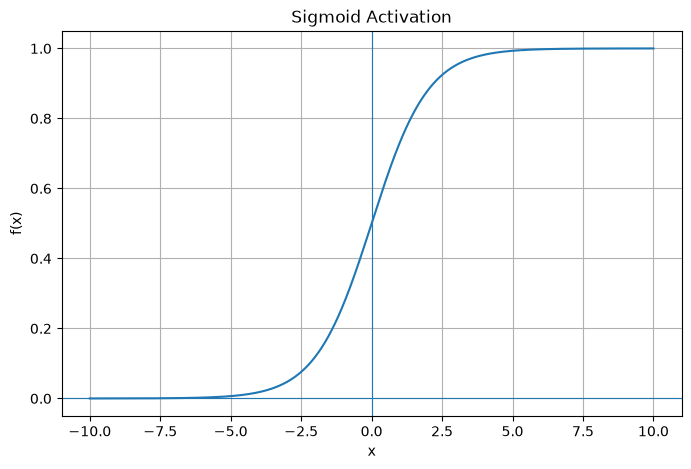

In [3]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

y_sigmoid = sigmoid(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y_sigmoid)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Sigmoid Activation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

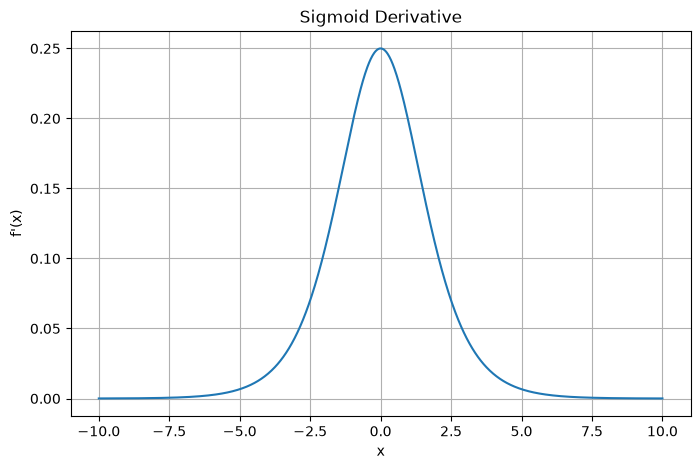

In [4]:
sigmoid_derivative = y_sigmoid * (1 - y_sigmoid)

plt.figure(figsize=(8, 5))
plt.plot(x, sigmoid_derivative)
plt.title("Sigmoid Derivative")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.grid()
plt.show()

### Tanh

Formula
tanh(x)= (e^x - e^{-x}) / (e^x + e^{-x})

Output range:

(-1,1)


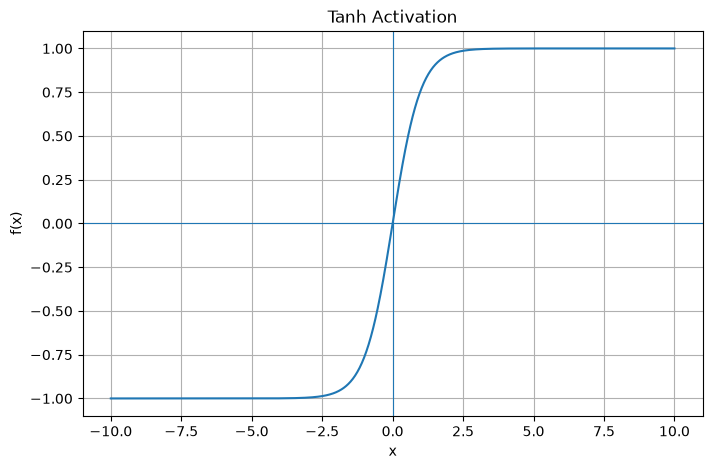

In [5]:
y_tanh = np.tanh(x)

plt.figure(figsize=(8, 5))
plt.plot(x, y_tanh)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Tanh Activation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

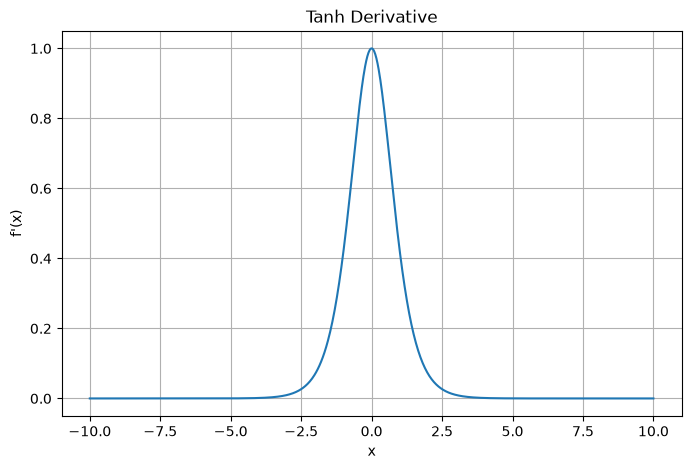

In [6]:
tanh_derivative = 1 - y_tanh**2

plt.figure(figsize=(8, 5))
plt.plot(x, tanh_derivative)
plt.title("Tanh Derivative")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.grid()
plt.show()

### ReLU

Formula

ReLU(x)= max(0,x)


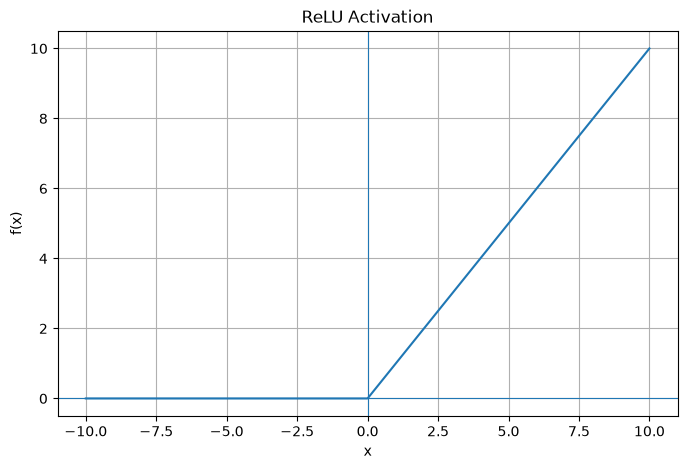

In [7]:
y_relu = np.maximum(0, x)

plt.figure(figsize=(8, 5))
plt.plot(x, y_relu)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("ReLU Activation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

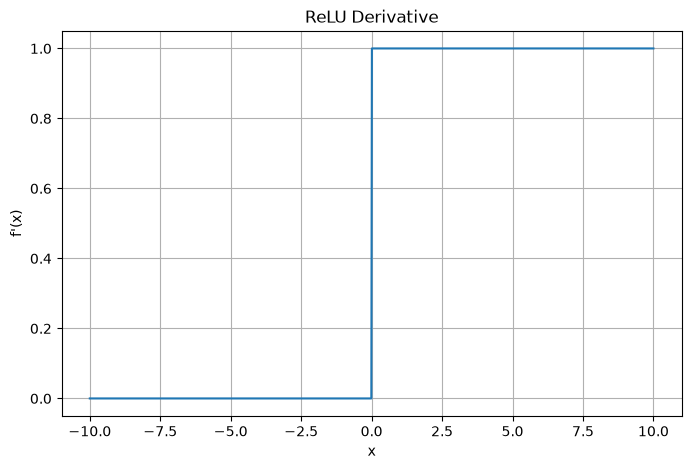

In [8]:
relu_derivative = np.where(x > 0, 1, 0)

plt.figure(figsize=(8, 5))
plt.plot(x, relu_derivative)
plt.title("ReLU Derivative")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.grid()
plt.show()

### Leaky ReLU

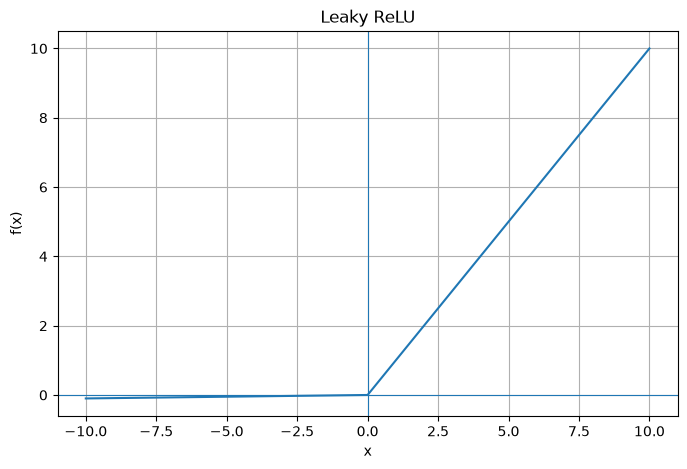

In [9]:
alpha = 0.01

y_leaky = np.where(x > 0, x, alpha * x)

plt.figure(figsize=(8, 5))
plt.plot(x, y_leaky)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Leaky ReLU")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

### PReLU

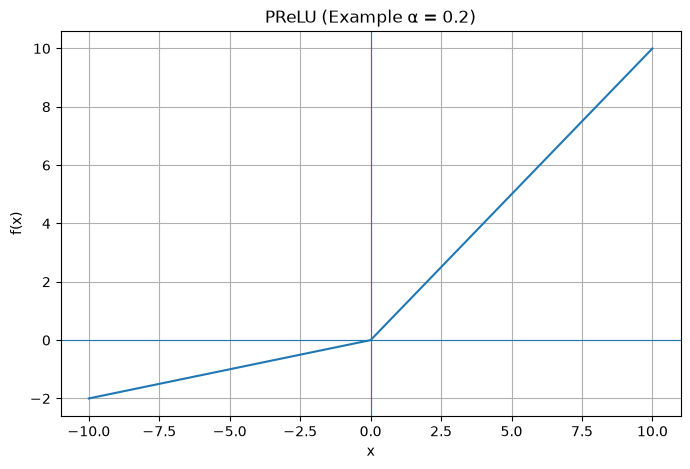

In [10]:
alpha = 0.2

y_prelu = np.where(x > 0, x, alpha * x)

plt.figure(figsize=(8, 5))
plt.plot(x, y_prelu)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("PReLU (Example α = 0.2)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

In [11]:
from tensorflow.keras.layers import PReLU

model = Sequential([
    Dense(64),
    PReLU(),
    Dense(32),
    PReLU(),
    Dense(1)
])

### ELU

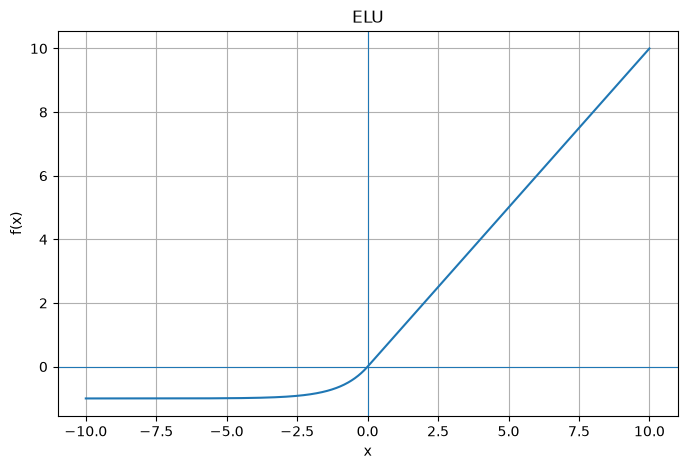

In [12]:
alpha = 1.0

y_elu = np.where(
    x > 0,
    x,
    alpha * (np.exp(x) - 1)
)

plt.figure(figsize=(8, 5))
plt.plot(x, y_elu)
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("ELU")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid()
plt.show()

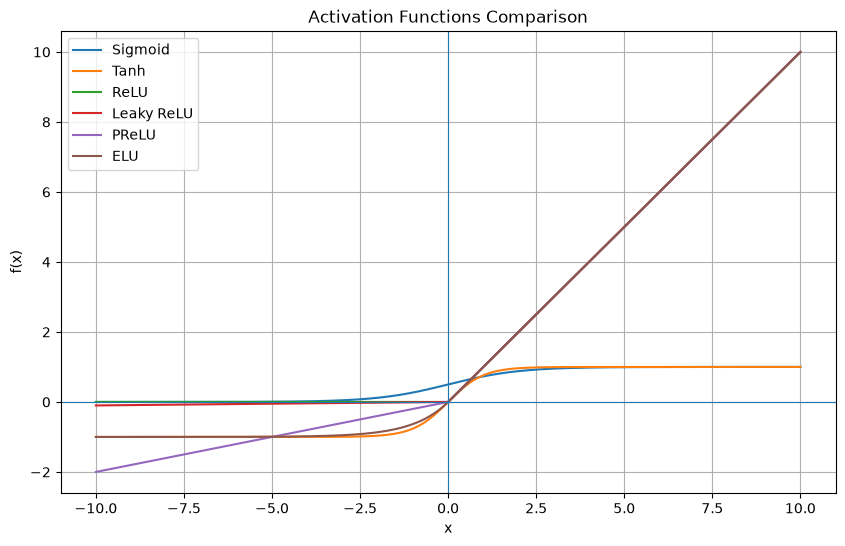

In [13]:
plt.figure(figsize=(10, 6))

plt.plot(x, sigmoid(x), label="Sigmoid")
plt.plot(x, np.tanh(x), label="Tanh")
plt.plot(x, np.maximum(0, x), label="ReLU")
plt.plot(x, np.where(x > 0, x, 0.01*x), label="Leaky ReLU")
plt.plot(x, np.where(x > 0, x, 0.2*x), label="PReLU")
plt.plot(x, np.where(x > 0, x, np.exp(x)-1), label="ELU")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("Activation Functions Comparison")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()
plt.show()

### Activation functions in Keras

In [14]:
model = Sequential([
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
model = Sequential([
    Dense(64, activation="tanh"),
    Dense(32, activation="tanh"),
    Dense(1, activation="sigmoid")
])

In [16]:
from tensorflow.keras.layers import LeakyReLU

model = Sequential([
    Dense(64),
    LeakyReLU(negative_slope=0.01),

    Dense(32),
    LeakyReLU(negative_slope=0.01),

    Dense(1, activation="sigmoid")
])

### Small practical classification example

In [17]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Dataset
X, y = make_moons(
    n_samples=2000,
    noise=0.2,
    random_state=42
)

# Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(2,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

c:\Users\alili\100_days_Deep_Learning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.0858447477221489
Test Accuracy: 0.9674999713897705


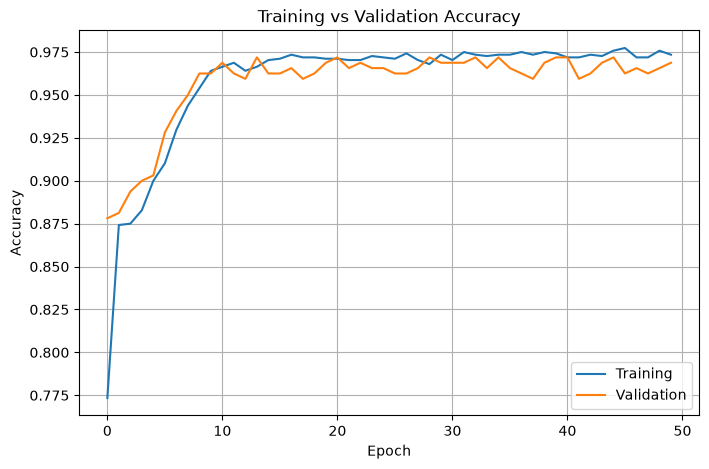

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()